[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/liamdev07/machine-learning-laboratory/blob/main/05_Decision_Tree_ID3/practical_05.ipynb)

# Practical 05 — Decision Tree using ID3 (Entropy)

## 1. Aim & Objectives

**Aim:** To implement a Decision Tree classifier using the ID3 approach (entropy and information gain) and analyse its performance.

**Objectives:**
1. Load the classic Play-Tennis dataset and convert its categorical columns into numbers.
2. Train a `DecisionTreeClassifier` with `criterion="entropy"`, which is the ID3 splitting rule.
3. Print the tree rules, check the accuracy, and plot the tree diagram.

## 2. Complete Python Code


Play Tennis dataset:
     outlook temperature humidity    wind play
0      sunny         hot     high    weak   no
1      sunny         hot     high  strong   no
2   overcast         hot     high    weak  yes
3       rain        mild     high    weak  yes
4       rain        cool   normal    weak  yes
5       rain        cool   normal  strong   no
6   overcast        cool   normal  strong  yes
7      sunny        mild     high    weak   no
8      sunny        cool   normal    weak  yes
9       rain        mild   normal    weak  yes
10     sunny        mild   normal  strong  yes
11  overcast        mild     high  strong  yes
12  overcast         hot   normal    weak  yes
13      rain        mild     high  strong   no

Class counts : {'yes': np.int64(9), 'no': np.int64(5)}
Entropy H(S) : 0.9403

Columns after encoding: ['outlook_overcast', 'outlook_rain', 'outlook_sunny', 'temperature_cool', 'temperature_hot', 'temperature_mild', 'humidity_high', 'humidity_normal', 'wind_strong', 'wind_w

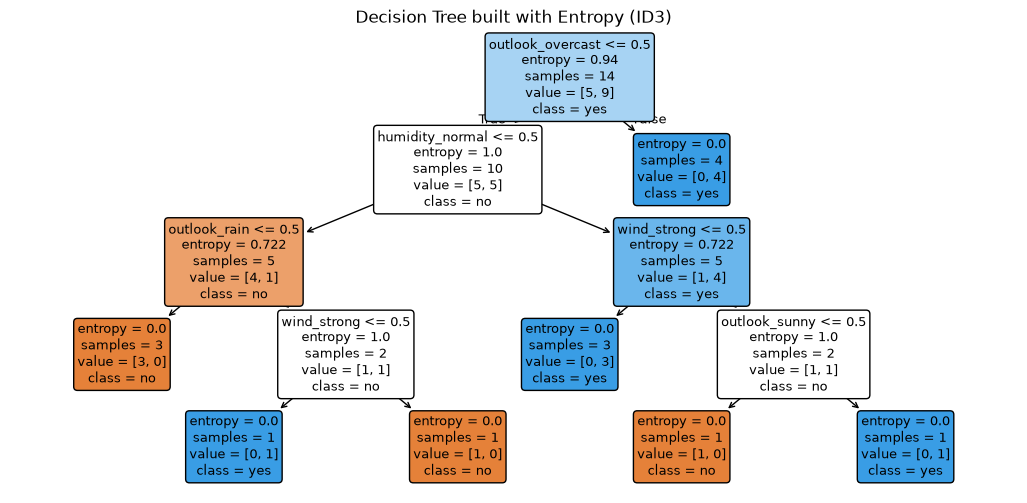

In [1]:
# Practical 05 - Decision Tree using ID3 (Entropy)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# Step 1: Load the dataset
CSV = "data/play_tennis.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/05_Decision_Tree_ID3/data/play_tennis.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path, encoding="utf-8-sig")

print("Play Tennis dataset:")
print(df)

# Step 2: Entropy of the whole dataset, calculated manually
counts = df["play"].value_counts()
p = counts / counts.sum()
entropy = -np.sum(p * np.log2(p))
print("\nClass counts :", dict(counts))
print("Entropy H(S) :", round(entropy, 4))

# Step 3: Convert text columns into 0/1 columns
X = pd.get_dummies(df.drop(columns="play"))
y = df["play"]
print("\nColumns after encoding:", list(X.columns))

# Step 4: Train the ID3 decision tree
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X, y)

# Step 5: Check performance and print the rules
y_pred = model.predict(X)
print("\nAccuracy :", accuracy_score(y, y_pred))
print("\nTree rules:")
print(export_text(model, feature_names=list(X.columns)))

# Step 6: Draw the tree
plt.figure(figsize=(13, 6))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Decision Tree built with Entropy (ID3)")
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree` — the tree model, a function that prints the rules as text, and a function that draws the tree.
- `pd.read_csv(path, encoding="utf-8-sig")` — reads the CSV. The `utf-8-sig` encoding removes an invisible marker character at the start of the file so the first column name is clean.
- `df["play"].value_counts()` — counts how many "yes" and "no" answers exist.
- `p = counts / counts.sum()` — converts those counts into probabilities.
- `-np.sum(p * np.log2(p))` — the entropy formula H(S) = −Σ p·log₂p. It measures how mixed the class labels are; 1.0 means completely mixed, 0.0 means pure.
- `pd.get_dummies(df.drop(columns="play"))` — one-hot encoding. Each text value such as `outlook=sunny` becomes its own 0/1 column, because Scikit-Learn works only with numbers.
- `y = df["play"]` — the target column, i.e. the answer the tree must learn.
- `DecisionTreeClassifier(criterion="entropy")` — builds the tree using information gain, which is exactly the ID3 rule. (`random_state=42` keeps the result identical on every run.)
- `model.fit(X, y)` — grows the tree by repeatedly choosing the feature with the highest information gain.
- `model.predict(X)` — the tree's answer for every row.
- `accuracy_score(y, y_pred)` — fraction of rows predicted correctly.
- `export_text(...)` — prints the tree as simple if/else rules that can be copied into an answer sheet.
- `plot_tree(..., filled=True)` — draws the tree; each box shows the test, the entropy, the number of samples and the predicted class. `filled=True` colours the boxes by class.
- `plt.show()` — displays the tree diagram.


## 4. Output & Graph Interpretation

The root of the tree is the `outlook` feature, because it gives the highest information gain from the starting entropy of about 0.94.

The accuracy is 1.0 since this small 14-row dataset is fully learned by the tree; on a larger dataset the tree would be pruned (for example with `max_depth`) to avoid overfitting.
